# Scenario 2 — combined method comparison

Compares five methods against the **MCMC** ground truth:

- **MCMC** (reference) and **PB** — from `output2.3` (the full final run)
- **RPS**, **AIS (RPS seed)**, **AIS (random seed)** — from `output2_combined`
  (the short-ladder run; `n_ladder` set in `simulation_scenario2_combined.py`)

The combined run and the reference run share the same per-replication data
(`np.random.seed(iter*42)`), so a replication in one is matched to the other by
a hash of its `y` vector. The RPS-seeded vs random-seeded AIS contrast isolates
**seed quality** under the reduced annealing budget.

In [1]:
import glob, pickle, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COMB_DIR = "./output2_combined"   # RPS, AIS (RPS seed), AIS (random seed)
REF_DIR  = "./output2.3"          # MCMC (ground truth) and PB

def _load(paths):
    d = []
    for p in sorted(paths):
        with open(p, "rb") as f:
            d.extend(pickle.load(f))
    return d

comb = _load(glob.glob(f"{COMB_DIR}/sim2_combined_result*.pkl"))
if not comb:
    raise FileNotFoundError(f"No combined result files in {COMB_DIR}")

# Combined script formats theta keys with {theta:g}, so theta=13.0 -> bare "13".
# Rename only the bare "13" token (not 13.1..13.4) to "13.0".
def _fix13(d):
    return {re.sub(r'(?<=_)13(?=_|$)', '13.0', k): v for k, v in d.items()}
comb = [_fix13(x) for x in comb]

ref = _load(glob.glob(f"{REF_DIR}/sim2_final_result*.pkl"))
if not ref:
    raise FileNotFoundError(f"No reference (MCMC/PB) files in {REF_DIR}")

# Align combined <-> reference by a hash of y (identical data per replication,
# both runs use the same iter*42 seeds). Robust to file ordering / partial runs.
def _yhash(x):
    return hash(np.asarray(x["y"]).tobytes())
ref_by_y = {_yhash(r): r for r in ref}

pairs, missing = [], 0
for x in comb:
    r = ref_by_y.get(_yhash(x))
    if r is None:
        missing += 1
        continue
    pairs.append((x, r))

thetas       = [13.0, 13.1, 13.2, 13.3, 13.4]
theta_keys   = [f"{t:g}" for t in thetas]
theta_keys[0] = "13.0"
theta_labels = [f"θ={t:g}" for t in thetas]

print(f"Combined reps: {len(comb)} | reference reps: {len(ref)} | matched pairs: {len(pairs)}")
if missing:
    print(f"WARNING: {missing} combined reps had no matching reference (skipped)")
print("n_ladder:", comb[0].get("n_ladder"),
      "| ladder:", np.round(np.asarray(comb[0].get("ladder", [])), 4))

Combined reps: 50 | reference reps: 50 | matched pairs: 50
n_ladder: 4 | ladder: [0.1259 0.2512 0.5012 1.    ]


## Collect per-replication metrics

In [2]:
def l1(a, b):
    return float(np.sum(np.abs(np.asarray(a) - np.asarray(b))))

def ci_iou(lo_m, hi_m, lo_ref, hi_ref):
    inter = np.maximum(0, np.minimum(hi_m, hi_ref) - np.maximum(lo_m, lo_ref))
    rl = hi_ref - lo_ref
    return float(np.nanmean(np.where(rl > 0, inter / rl, np.nan)))

def n_states_of(d, pref):
    if f"{pref}_n_states" in d:
        return d[f"{pref}_n_states"]
    out = d.get(f"{pref}_output")
    return len(out.terminals) if out is not None else np.nan

# (label, source, key-prefix): source 'C' = combined rep, 'R' = reference rep
METHODS = [
    ("RPS",               "C", "RPS"),
    ("AIS (RPS seed)",    "C", "AIS"),
    ("AIS (random seed)", "C", "AIS_rand"),
    ("PB",                "R", "PB"),
]

rows = []
for x, r in pairs:
    mc = np.asarray(r["MCMC"])
    lo = r["MCMC_quantiles"]["0.025"]; hi = r["MCMC_quantiles"]["0.975"]
    for key in theta_keys:
        for name, src, base in METHODS:
            d = x if src == "C" else r
            pref = f"{base}_{key}"
            if pref not in d:
                continue
            q = d[f"{pref}_quantiles"]
            rows.append(dict(
                method=name, theta=float(key),
                n_states=n_states_of(d, pref),
                runtime_s=d.get(f"{pref}_time", np.nan),
                L1_mean=l1(d[pref], mc),
                L1_q025=l1(q["0.025"], lo),
                L1_q975=l1(q["0.975"], hi),
                IoU=ci_iou(q["0.025"], q["0.975"], lo, hi),
            ))

df = pd.DataFrame(rows)
print("rows per method:")
print(df.method.value_counts())
summary = (df.groupby("method")
             [["n_states", "L1_mean", "L1_q025", "L1_q975", "IoU", "runtime_s"]]
             .mean().round(4))
summary

rows per method:
method
RPS                  250
AIS (RPS seed)       250
AIS (random seed)    250
PB                   250
Name: count, dtype: int64


,n_states,L1_mean,L1_q025,L1_q975,IoU,runtime_s
method,,,,,,
AIS (RPS seed),300.000,6.0744,0.3439,0.4424,0.9848,49.2089
AIS (random seed),300.000,3.3285,0.1920,0.2331,0.9943,49.1982
PB,400.752,10.8668,1.2063,1.6974,0.9545,619.0357
RPS,100.752,14.9624,5.8240,9.0676,0.8193,NaN


## Posterior-mean and quantile error vs MCMC

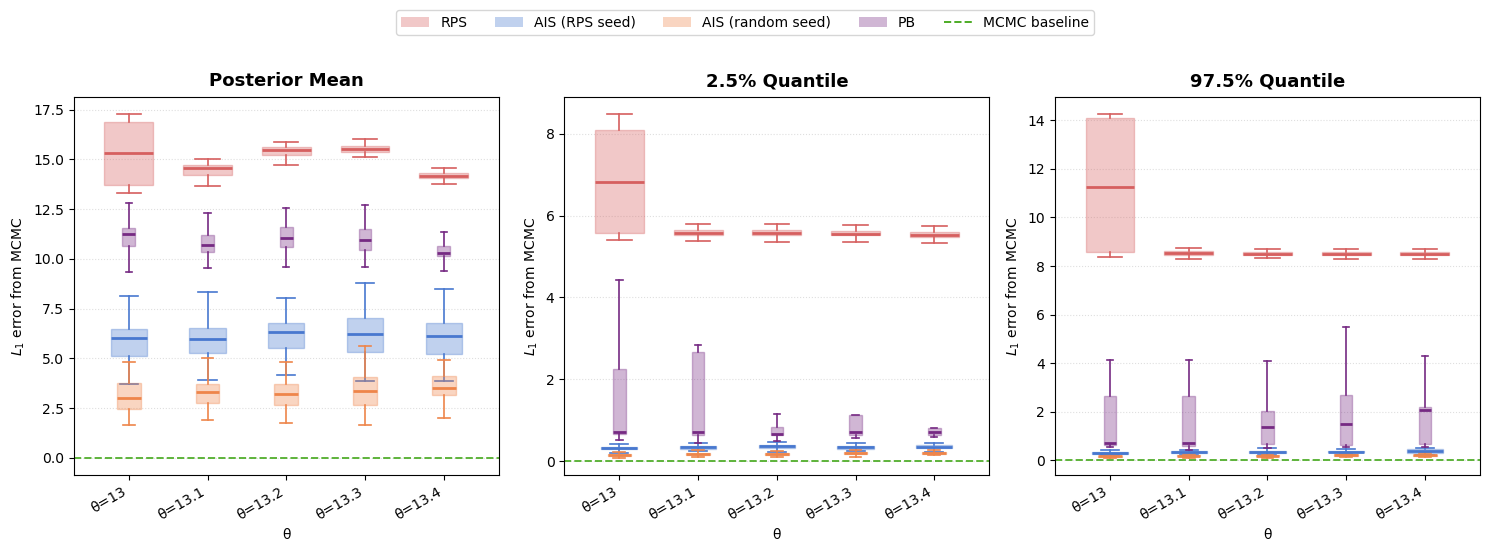

In [3]:
rps_color      = "#D65F5F"
ais_color      = "#4878CF"
ais_rand_color = "#EE854A"
pb_color       = "#762a83"
mcmc_color     = "#4DAC26"

# (label, color, box width) — nested widths so all four are visible
method_style = [
    ("RPS",               rps_color,      0.62),
    ("AIS (RPS seed)",    ais_color,      0.46),
    ("AIS (random seed)", ais_rand_color, 0.30),
    ("PB",                pb_color,       0.16),
]

def aligned_boxplot(ax, values, positions, color, width=0.48, alpha=0.34):
    bp = ax.boxplot(values, positions=positions, widths=width,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color, linewidth=1.2),
                    capprops=dict(color=color, linewidth=1.2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color); patch.set_edgecolor(color); patch.set_alpha(alpha)
    return bp

panels    = [("Posterior Mean", "L1_mean"), ("2.5% Quantile", "L1_q025"), ("97.5% Quantile", "L1_q975")]
theta_pos = np.arange(1, len(thetas) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, col) in zip(axes, panels):
    for name, color, width in method_style:
        vals = [df[(df.method == name) & (df.theta == t)][col].dropna().values for t in thetas]
        aligned_boxplot(ax, vals, theta_pos, color, width=width)
    ax.axhline(0, color=mcmc_color, linestyle="--", linewidth=1.4, alpha=0.9)
    ax.set_xticks(list(theta_pos))
    ax.set_xticklabels(theta_labels, rotation=30, ha="right")
    ax.set_xlim(0.3, len(thetas) + 0.7)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("$L_1$ error from MCMC")
    ax.set_xlabel("θ")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

legend_elements = [Patch(facecolor=c, alpha=0.34, label=n) for n, c, _ in method_style]
legend_elements.append(plt.Line2D([0], [0], color=mcmc_color, linestyle="--", linewidth=1.4, label="MCMC baseline"))
fig.legend(handles=legend_elements, loc="lower center", ncol=5, frameon=True, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.savefig("../Figures/simulation2_combined_errors.png", dpi=150, bbox_inches="tight")
plt.show()

## 95% CI overlap (IoU) with MCMC

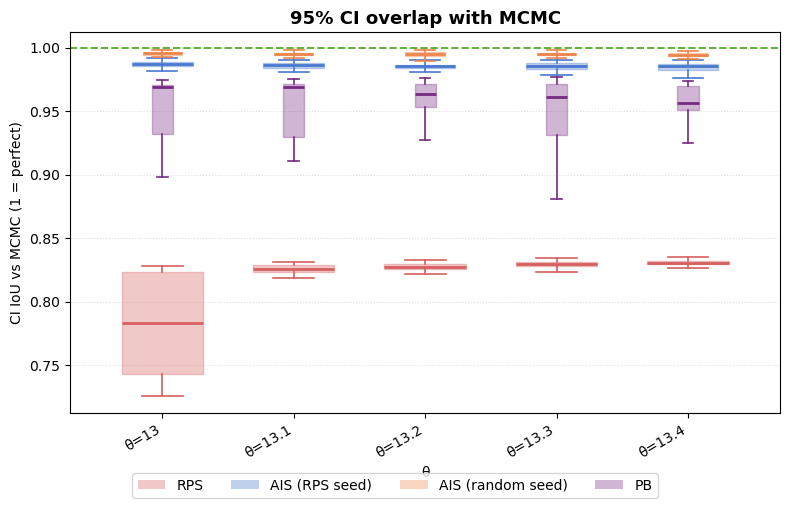

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, color, width in method_style:
    vals = [df[(df.method == name) & (df.theta == t)]["IoU"].dropna().values for t in thetas]
    aligned_boxplot(ax, vals, theta_pos, color, width=width)
ax.axhline(1.0, color=mcmc_color, linestyle="--", linewidth=1.4, alpha=0.9)
ax.set_xticks(list(theta_pos))
ax.set_xticklabels(theta_labels, rotation=30, ha="right")
ax.set_xlim(0.3, len(thetas) + 0.7)
ax.set_ylabel("CI IoU vs MCMC (1 = perfect)")
ax.set_xlabel("θ")
ax.set_title("95% CI overlap with MCMC", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle=":", alpha=0.4)
legend_elements = [Patch(facecolor=c, alpha=0.34, label=n) for n, c, _ in method_style]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("../Figures/simulation2_combined_iou.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary broken out by theta

In [5]:
summary_theta = (df.groupby(["theta", "method"])
                   [["n_states", "L1_mean", "L1_q025", "L1_q975", "IoU", "runtime_s"]]
                   .mean().round(4))
summary_theta

n_states  L1_mean  L1_q025  L1_q975     IoU  \
theta method                                                           
13.0  AIS (RPS seed)       300.00   5.8537   0.3143   0.3342  0.9867   
      AIS (random seed)    300.00   3.1114   0.1580   0.1674  0.9956   
      PB                   341.88  11.1774   1.3059   1.4569  0.9559   
      RPS                   41.88  15.2591   6.8591  11.3082  0.7829   
13.1  AIS (RPS seed)       300.00   5.9354   0.3353   0.4121  0.9852   
      AIS (random seed)    300.00   3.3250   0.1884   0.2199  0.9944   
      PB                   374.86  10.7622   1.3308   1.4770  0.9554   
      RPS                   74.86  14.4900   5.5808   8.5229  0.8255   
13.2  AIS (RPS seed)       300.00   6.3053   0.3600   0.4020  0.9845   
      AIS (random seed)    300.00   3.2037   0.1873   0.2622  0.9937   
      PB                   402.30  11.0402   1.0261   1.6509  0.9574   
      RPS                  102.30  15.3977   5.5747   8.5094  0.8275   
13.3  AIS (RPS seed)       300.00   6.1929   0.3438   0.4086  0.9849   
      AIS (random seed)    300.00   3.4051   0.2121   0.3032  0.9936   
      PB                   434.60  11.0067   1.2619   1.9302  0.9518   
      RPS                  134.60  15.5048   5.5683   8.5083  0.8297   
13.4  AIS (RPS seed)       300.00   6.0847   0.3660   0.6549  0.9827   
      AIS (random seed)    300.00   3.5974   0.2142   0.2128  0.9942   
      PB                   450.12  10.3472   1.1069   1.9718  0.9523   
      RPS                  150.12  14.1604   5.5373   8.4893  0.8307   

                         runtime_s  
theta method                        
13.0  AIS (RPS seed)       49.3056  
      AIS (random seed)    49.2387  
      PB                  603.4623  
      RPS                      NaN  
13.1  AIS (RPS seed)       49.1224  
      AIS (random seed)    49.1689  
      PB                  620.3921  
      RPS                      NaN  
13.2  AIS (RPS seed)       49.1632  
      AIS (random seed)    49.1908  
      PB                  621.1175  
      RPS                      NaN  
13.3  AIS (RPS seed)       49.2051  
      AIS (random seed)    49.1873  
      PB                  622.6985  
      RPS                      NaN  
13.4  AIS (RPS seed)       49.2484  
      AIS (random seed)    49.2052  
      PB                  627.5081  
      RPS                      NaN

## Seed-quality contrast: RPS-seeded vs random-seeded AIS

Both AIS variants come from the same short-ladder combined run, so this isolates
the effect of the seed set. `rand_minus_rps > 0` means random-start is worse.

In [6]:
comp = []
for x, r in pairs:
    mc = np.asarray(r["MCMC"])
    for key in theta_keys:
        a, b = f"AIS_{key}", f"AIS_rand_{key}"
        if a in x and b in x:
            comp.append(dict(theta=float(key),
                L1_AIS_MCMC=l1(x[a], mc),
                L1_AISrand_MCMC=l1(x[b], mc),
                L1_AISrand_AIS=l1(x[b], x[a])))
comp = pd.DataFrame(comp)
tbl = comp.groupby("theta")[["L1_AIS_MCMC", "L1_AISrand_MCMC", "L1_AISrand_AIS"]].mean().round(4)
tbl["rand_minus_rps"] = (tbl["L1_AISrand_MCMC"] - tbl["L1_AIS_MCMC"]).round(4)
tbl

,L1_AIS_MCMC,L1_AISrand_MCMC,L1_AISrand_AIS,rand_minus_rps
theta,,,,
13.0,5.8537,3.1114,6.3053,-2.7423
13.1,5.9354,3.3250,6.5636,-2.6104
13.2,6.3053,3.2037,6.7130,-3.1016
13.3,6.1929,3.4051,7.0261,-2.7878
13.4,6.0847,3.5974,6.6774,-2.4873
